In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import tqdm
import glob
import re
import pickle
import os
from typing import List
import seaborn as sns
#sns.set() #推奨されないみたい
sns.set_style("white"+"grid")
sns.set_palette("Paired")
import time

plt.rcParams['font.family'] = 'Times New Roman' # Fonts
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 24 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます
color_arr=plt.rcParams['axes.prop_cycle'].by_key()['color']

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
#folder_name="secureRA-addAttackerAppearParam"
data_folder_name="data"
#CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"../{folder_name}/{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"./{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST

['./data/zmethodCmp2dpL2',
 './data/methodCmp2dL2',
 './data/checkLambda2d',
 './data/zmethodCmp2dp',
 './data/methodCmp1d',
 './data/methodCmp2dv2',
 './data/zmethodCmp2dpL2v2',
 './data/checkLambda1d',
 './data/checkLambda2dL',
 './data/methodCmp2dL2v2',
 './data/methodCmp2d',
 './data/methodCmp1dv2',
 './data/methodCmp1dL2v2',
 './data/methodCmp1dL2']

In [3]:
MAX_DF_SEED_LENGTH=1000

In [79]:
def isFloat(s:str)->bool:
    try:
        float(s)
        return True
    except:
        return False

# REQUIRE FileName : /{x}_{parameter_name}_{value}_..._{parameter_name}_{value}_.csv
def make_FileName_Parameter_dict(FileName:str) -> dict:
    FileNameSplit=FileName.split("\\")[-1].split(".csv")[0].split("_")[::-1]
    res={}
    for i in range(len(FileNameSplit)):
        if isFloat(FileNameSplit[i]):
            res[FileNameSplit[i+1]]=float(FileNameSplit[i])
    return {key:res[key] for key in reversed(list(res.keys()))}

def fix_parameter_line_to_dict(parameter_string:str):
    response={}
    key=""
    for x in parameter_string.split("_"):
        if not isFloat(x):
            if not '~' in x:
                if key!="":
                    key+="_"
                key+=x
            else:
                list_param=x.split('~')
                if len(list_param)>2:
                    response[list_param[0]]=','.join(list_param[1:-1])
        else:
            response[key]=float(x)
            key=""
    return response


def make_describe_csv(FileName : str) -> dict:
    df=pd.read_csv(FileName,skiprows=1)
    with open(FileName) as f:
        parameter_line=f.readline()
    response=fix_parameter_line_to_dict(parameter_line)
    df=df[:MAX_DF_SEED_LENGTH]
    response["length"]=len(df)
    response["time"]=df["time"].mean()
    
    response["mean_receive_duration"]=((df[["last_true_receive","last_fake_receive"]].max(axis=1))-df["first_true_receive"]).mean()
    response["mean_broadcast_duration"]=((df[["last_true_broadcast","last_fake_broadcast"]].max(axis=1))-df["first_true_broadcast"]).mean()
    response["min_broadcast_duration"]=((df[["last_true_broadcast","last_fake_broadcast"]].max(axis=1))-df["first_true_broadcast"]).min()

    response["mean_true_receive_duration"]=(df["last_true_receive"]-df["first_true_receive"]).mean()
    response["mean_true_broadcast_duration"]=(df["last_true_broadcast"]-df["first_true_broadcast"]).mean()
    response["min_true_broadcast_duration"]=(df["last_true_broadcast"]-df["first_true_broadcast"]).min()

    response["mean_connect"]=df["connect"].mean()
    response["mean_broadcast"]=df["broadcast"].mean()
    
    response["result_draw"]=len(df[(df["true"]>0) & (df["fake"]>0)])
    response["result_true"]=len(df[(df["true"]>0) & (df["fake"]==0)])
    response["result_fake"]=len(df[(df["true"]==0) & (df["fake"]>0)])
    response["result_none"]=len(df[(df["true"]==0) & (df["fake"]==0)])
    response["result_fail"]=len(df[(df["last_fake_broadcast"]==0)])
    
    response["result_draw_rate"]=round(response["result_draw"]/response["length"],5)
    response["result_true_rate"]=round(response["result_true"]/response["length"],5)
    response["result_fake_rate"]=round(response["result_fake"]/response["length"],5)
    response["result_none_rate"]=round(response["result_none"]/response["length"],5)
    response["result_fail_rate"]=round(response["result_fail"]/response["length"],5)

    response["mean_in_RA"]=df["RAin"].mean()

    return response

def make_data_dict(FileNameList):
    response={}
    for Filename in tqdm.tqdm(FileNameList):
        try:
            result_dict=make_describe_csv(Filename)
            for key in result_dict:
                if key not in response:
                    response[key] = []
                response[key].append(result_dict[key])
        except Exception as e:
            print(Filename,e)
    return response

def pickle_dump(obj,path=f"test.pkl"):
    with open(path,mode="wb") as f:
        pickle.dump(obj,file=f)

def pickle_load(path=f"test.pkl"):
    with open(path,mode="rb") as f:
        res=pickle.load(f)
    return res

In [80]:
#CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"../{folder_name}/{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"./{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST=[x for x in CSV_DATA_FOLDER_PATH_LIST if "z" not in x]
CSV_DATA_FOLDER_PATH_LIST

['./data/methodCmp2dL2',
 './data/pkl',
 './data/checkLambda2d',
 './data/methodCmp1d',
 './data/methodCmp2dv2',
 './data/checkLambda1d',
 './data/checkLambda2dL',
 './data/methodCmp2dL2v2',
 './data/methodCmp2d',
 './data/methodCmp1dv2',
 './data/methodCmp1dL2v2',
 './data/methodCmp1dL2']

In [81]:
def make_csv_pkl(base_file_name:str,save_folder:str="data",data_tag:str="notag",folder_name_list=None,exist_skip=True):
    FileNameList=glob.glob(base_file_name+"/*",recursive=False)
    if folder_name_list==None:
        folder_name_list=[x.split("/")[-1] for x in FileNameList]
    print(folder_name_list)
    for folder_name in folder_name_list:
        print(f"search  {base_file_name}/{folder_name}/*.csv")
        CsvFileNameList=glob.glob(f"{base_file_name}/{folder_name}/*.csv",recursive=False)
        print("file name list", folder_name, "size :",len(CsvFileNameList))
        data_file_string=f"{data_tag}/{folder_name}/"
        if os.path.exists(f"{save_folder}/pkl/"+data_file_string+"pandas_data.pkl")==False or exist_skip==False or len(CsvFileNameList)!=len(pickle_load(f"{save_folder}/pkl/"+data_file_string+"pandas_data.pkl")):
            res=make_data_dict(CsvFileNameList)
            df=pd.DataFrame(res)
            pkl_save_folder=f"{save_folder}/pkl/"+data_file_string
            os.makedirs(pkl_save_folder,exist_ok=True)
            pickle_dump(df,pkl_save_folder+"pandas_data.pkl")
            print(pkl_save_folder+"pandas_data.pkl")

def get_NoAttacker_Value(df:pd.DataFrame,Lambda:float,Nx:int,Ny:int,Method:int,column:str) -> any:
    values=df[(df["Lambda"]==Lambda) & (df["Nx"]==Nx) & (df["Ny"]==Ny) & (df["Method"]==Method)][column].values
    if len(values)==1:
        return values[0]
    else:
        raise Exception(f"values : {len(values)}")
#get_NoAttacker_Value(dfs["NoAttacker"],0.001,1,0,1,"mean_broadcast_duration")


In [82]:
data_file_from="rep2"
#CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"../{folder_name}/{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST=glob.glob(f"./{data_folder_name}/*")
CSV_DATA_FOLDER_PATH_LIST=[re.findall(f"{data_folder_name}/(.*)",x)[0] for x in CSV_DATA_FOLDER_PATH_LIST if "z" not in x]
CSV_DATA_FOLDER_PATH_LIST

['methodCmp2dL2',
 'pkl',
 'checkLambda2d',
 'methodCmp1d',
 'methodCmp2dv2',
 'checkLambda1d',
 'checkLambda2dL',
 'methodCmp2dL2v2',
 'methodCmp2d',
 'methodCmp1dv2',
 'methodCmp1dL2v2',
 'methodCmp1dL2']

In [83]:
#make_csv_pkl(f"../{folder_name}/{data_folder_name}",save_folder=f"{data_folder_name}",data_tag=data_file_from,folder_name_list=CSV_DATA_FOLDER_PATH_LIST,exist_skip=False)
make_csv_pkl(f"./{data_folder_name}",save_folder=f"{data_folder_name}",data_tag=data_file_from,folder_name_list=CSV_DATA_FOLDER_PATH_LIST,exist_skip=False)

['methodCmp2dL2', 'pkl', 'checkLambda2d', 'methodCmp1d', 'methodCmp2dv2', 'checkLambda1d', 'checkLambda2dL', 'methodCmp2dL2v2', 'methodCmp2d', 'methodCmp1dv2', 'methodCmp1dL2v2', 'methodCmp1dL2']
search  ./data/methodCmp2dL2/*.csv
file name list methodCmp2dL2 size : 110


100%|██████████| 110/110 [00:01<00:00, 56.92it/s]


data/pkl/rep2/methodCmp2dL2/pandas_data.pkl
search  ./data/pkl/*.csv
file name list pkl size : 0


0it [00:00, ?it/s]


data/pkl/rep2/pkl/pandas_data.pkl
search  ./data/checkLambda2d/*.csv
file name list checkLambda2d size : 10


...

data/pkl/rep2/methodCmp1dv2/pandas_data.pkl
search  ./data/methodCmp1dL2v2/*.csv
file name list methodCmp1dL2v2 size : 110


100%|██████████| 110/110 [00:01<00:00, 72.12it/s]


data/pkl/rep2/methodCmp1dL2v2/pandas_data.pkl
search  ./data/methodCmp1dL2/*.csv
file name list methodCmp1dL2 size : 110


100%|██████████| 110/110 [00:01<00:00, 66.17it/s]

data/pkl/rep2/methodCmp1dL2/pandas_data.pkl


In [84]:
data_names=[x.split("/")[-1] for x in glob.glob(f"{data_folder_name}/pkl/{data_file_from}/*",recursive=False)]
print(data_names)
dfs={}
for i in data_names:
    if i!="pkl":
        print(i)
        data_file_string=f"{data_file_from}/{i}/"
        pkl_save_folder=f"{data_folder_name}/pkl/"+data_file_string
        dfs[i]=pickle_load(pkl_save_folder+"pandas_data.pkl")
    
columns=list(dfs[i].columns)
parameter_key=columns[:columns.index("length")]

['methodCmp2dL2', 'pkl', 'checkLambda2d', 'methodCmp1d', 'methodCmp2dv2', 'checkLambda1d', 'checkLambda2dL', 'methodCmp2dL2v2', 'methodCmp2d', 'methodCmp1dv2', 'methodCmp1dL2v2', 'methodCmp1dL2']
methodCmp2dL2
checkLambda2d
methodCmp1d
methodCmp2dv2
checkLambda1d
checkLambda2dL
methodCmp2dL2v2
methodCmp2d
methodCmp1dv2
methodCmp1dL2v2
methodCmp1dL2


In [85]:
for key in dfs.keys():
    print(key)
    column=list(dfs[key].columns)
    dfs[key]["TAsize"]=[float(x.split(",")[-1]) for x in dfs[key]["TA"]]
    column.insert(column.index("length"),"TAsize")
    dfs[key]["fTAsize"]=[float(x.split(",")[-1]) for x in dfs[key]["fTA"]]
    column.insert(column.index("length"),"fTAsize")
    dfs[key]=dfs[key].reindex(columns=column)

methodCmp2dL2
checkLambda2d
methodCmp1d
methodCmp2dv2
checkLambda1d
checkLambda2dL
methodCmp2dL2v2
methodCmp2d
methodCmp1dv2
methodCmp1dL2v2
methodCmp1dL2


In [86]:
def get_parameter_list_dict(df:pd.DataFrame,parameter_key) -> dict:
    parameter_list_dict={}
    df[parameter_key[0]].unique().sort()
    for i in parameter_key:
        unique_parameter_values=df[i].unique()
        if len(unique_parameter_values)>1:
            parameter_list_dict[i]=np.sort(unique_parameter_values)
    return parameter_list_dict

def get_parameter_sets(arg_df:pd.DataFrame,columns):
    """
    DataFrameに含まれるパラメータの組み合わせを返す関数
    
    :param pd.DataFrame arg_df: パラメータを探索する対象のdf
    :param list[str] columns: パラメータを探索するカラムのリスト
    :return restrictions: パラメータの組み合わせをまとめたdictのlist 
    """
    restrictions=[]
    def get_restrictions(arg_df:pd.DataFrame,columns,columns_index=0,restriction={}):
        if columns_index==0:
            restriction={}
        if len(arg_df[columns[columns_index]].unique())>0:
            for i in arg_df[columns[columns_index]].unique():
                restriction[columns[columns_index]]=i
                if columns_index==len(columns)-1:
                    restrictions.append(restriction.copy())
                else:
                    get_restrictions(arg_df[(arg_df[columns[columns_index]]==i)],columns,columns_index+1,restriction)
    get_restrictions(arg_df,columns)
    return restrictions

In [87]:
label_dict={
    "Method":{1.0:"Method2", 3.0:"Method1", 5.0:"Method3", 7.0:"Method5", 8.0:"Method3.2"} # Method2 : New, Method1 : Old, Method3: Times
}
for i in range(len(dfs)):
    print(i,list(dfs.keys())[i])

0 methodCmp2dL2
1 checkLambda2d
2 methodCmp1d
3 methodCmp2dv2
4 checkLambda1d
5 checkLambda2dL
6 methodCmp2dL2v2
7 methodCmp2d
8 methodCmp1dv2
9 methodCmp1dL2v2
10 methodCmp1dL2


In [88]:
noAtk=dfs["checkLambda2d"].sort_values("Lambda")
print("Lambda",noAtk["Lambda"].unique())
for l in noAtk["Lambda"].unique():
    print(l,noAtk[noAtk["Lambda"]==l]["mean_broadcast_duration"].values[0],"len:",len(noAtk[noAtk["Lambda"]==l]["mean_broadcast_duration"].values))

Lambda

 [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01 ]
0.001 1685.321 len: 1
0.002 6696.708 len: 1
0.003 30152.374 len: 1
0.004 47280.137 len: 1
0.005 49857.959 len: 1
0.006 50000.0 len: 1
0.007 50000.0 len: 1
0.008 49950.8 len: 1
0.009 50000.0 len: 1
0.01 50000.0 len: 1


In [89]:
label_name = {
    'Lambda':r'$\lambda$',
    'malicious_appear_interval':r'$t_{interval} [s]$',
    'malicious_appear_num':r'$N_{attacker}$',
    'malicious_appear_type':r'$Appear Type$',
    'fTAsize':r"$L'_{TA}$ [m]"
}

In [90]:
df_name="methodCmp1d"
#df_name="mess1d"
df=dfs[df_name].sort_values("Method")
columns=list(df.columns)
get_parameter_list_dict(df,parameter_key=columns[:columns.index("length")])

{'Method': array([ 1.,  3.,  5.,  7.,  8.,  9., 12., 15., 18., 21., 24.]),
 'fTA': array(['2000,2000,10,10', '2000,2000,1200,1200', '2000,2000,1600,1600',
        '2000,2000,200,200', '2000,2000,2400,2400', '2000,2000,3200,3200',
        '2000,2000,400,400', '2000,2000,4000,4000', '2000,2000,600,600',
        '2000,2000,800,800'], dtype=object),
 'fTAsize': array([  10.,  200.,  400.,  600.,  800., 1200., 1600., 2400., 3200.,
        4000.])}

In [91]:
df[(df["malicious_appear_interval"]==0) & (df["malicious_appear_num"]==1) & (df["malicious_appear_type"]==1) & (df["fTAsize"]==800.0)]["mean_true_broadcast_duration"].sort_index()

25     50000.000
32     50000.000
46     50000.000
49     50000.000
58      5924.781
59     50000.000
79     50000.000
88     48465.249
102    50000.000
106    50000.000
108    50000.000
Name: mean_true_broadcast_duration, dtype: float64

noAtk val : 1000.00
[  10.  200.  400.  600.  800. 1200. 1600. 2400. 3200. 4000.]
3.0 [581 581 581 581 581 581 581 581 581 581]
1.0 [581 581 581 581 581 581 581 581 581 581]
5.0 [581 581 581 581 581 581 581 581 581 581]
8.0 [581 581 581 581 581 581 581 581 581 581]
9.0 [581 581 581 581 581 581 581 581 581 581]
12.0 [581 581 581 581 581 581 581 581 581 581]
15.0 [581 581 581 581 581 581 581 581 581 581]
18.0 [581 581 581 581 581 581 581 581 581 581]
21.0 [581 581 581 581 581 581 581 581 581 581]
24.0 [581 581 581 581 581 581 581 581 581 581]
7.0 [581 581 581 581 581 581 581 581 581 581]
{}


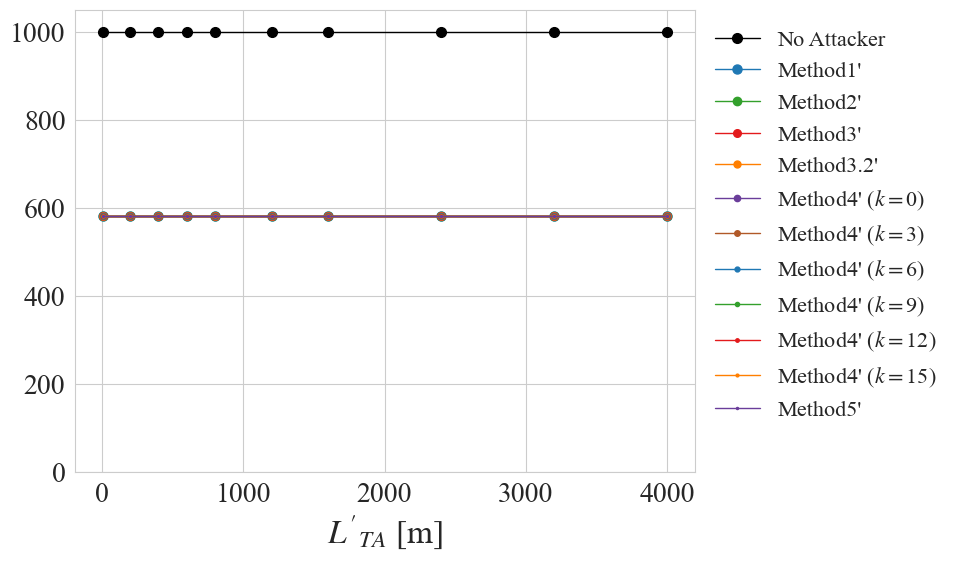

In [95]:
X="fTAsize"
#X="malicious_appear_interval"
Y="mean_true_broadcast_duration"
Y="mean_broadcast_duration"
Y="mean_broadcast"
Y="result_fail"
L="Method"

dim="2d"
sub="L2"
df_name=f"methodCmp{dim}"+sub

noAtk=dfs[f"checkLambda{dim}{''}"]
noAtk["Lambda"].unique()

df=dfs[df_name].sort_values("mean_broadcast_duration")
columns=list(df.columns)
parameter_list_dict = get_parameter_list_dict(df,parameter_key=columns[:columns.index("length")])
if (1.0 in parameter_list_dict["Method"]) and (3.0 in parameter_list_dict["Method"]):
    parameter_list_dict["Method"] = [3.0,1.0] + [x for x in parameter_list_dict["Method"] if x not in [1.0,3.0]]
if 7.0 in parameter_list_dict["Method"]:
    parameter_list_dict["Method"] = [x for x in parameter_list_dict["Method"] if x!=7.0]+[7.0]

Lambda = df["Lambda"].unique()[0]

lock = {
    #"malicious_appear_type":parameter_list_dict["malicious_appear_type"][0],
    #"malicious_appear_interval":parameter_list_dict["malicious_appear_interval"][0],
    #"malicious_appear_num":parameter_list_dict["malicious_appear_num"][0],
    #"fTAsize":parameter_list_dict["fTAsize"][2],
    }
if X in lock.keys():
    lock.pop(X)

fig=plt.figure(figsize=(8,6))
axe=fig.add_subplot(111)
marker_size=7.0;line_width=2.0;color_arr_i=1
for method in parameter_list_dict["Method"]:
    noAtk_val=noAtk[(noAtk["Lambda"]==Lambda)][Y].values[0]
print(f"noAtk val : {noAtk_val:.2f}")
x=parameter_list_dict[X]
print(x)
line_width=1.0
marker_size=7.0;color_arr_i=1
axe.plot(x,[noAtk_val]*len(x),marker="o",
            markersize=marker_size,linewidth=line_width,
            color="k",
            label=f"No Attacker")
marker_size-=0.5

cond = True
for k,v in lock.items():
    cond = cond & (df[k]==v)

plot_df=df[(df["Lambda"]==Lambda) & (cond)].sort_values(X)

for l in parameter_list_dict[L]:
    y=plot_df[(plot_df[L]==l)][Y]
    print(l,y.values)
    if l in label_dict[L].keys():
        label=f"{label_dict[L][l]}'"+("'" if "v2" in df_name else "")
        if 1:
            axe.plot(x,y,marker="o",
                    markersize=marker_size,linewidth=line_width,
                    color=color_arr[color_arr_i],
                    label=label
            )
            color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
            marker_size-=0.5
            
    else:
        label=f"Method4'"+("'" if "v2" in df_name else "")+" ("+r"$k=$"+f"{l-9.0:.0f})"
        axe.plot(x,y,marker="o",
                markersize=marker_size,linewidth=line_width,
                color=color_arr[color_arr_i],
                label=label
        )
        color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
        marker_size-=0.5

if Y=="mean_broadcast_duration":
    axe.set_ylim(0,52000)
    axe.set_ylabel(r"$E(T_{f})$ [s]")
if Y=="mean_true_broadcast_duration":
    axe.set_ylim(0,52000)
    axe.set_ylabel(r"$E(T_{f_{true}})$ [s]")
if Y=="mean_broadcast":
    axe.set_ylim(0)
    #axe.set_xticks([1000,2000,3000,4000])
    axe.set_ylabel(r"$E(N_{b})$")
if "result" in Y:
    if "ratio" in Y:
        axe.set_ylim(0,1.05)
    else:
        axe.set_ylim(0,1050)
    axe.set_label(r"$fail$")

axe.set_xlabel(label_name[X])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16, frameon=False)
print(lock)
if 0:
    os.makedirs(f"fig/rep20251029-2d/Lambda={Lambda}/",exist_ok=True)
    fig.savefig(f"fig/rep20251029-2d/Lambda={Lambda}/{Y}_{X}_MINTV_{lock['malicious_appear_interval']}_MAPTYPE_{lock['malicious_appear_type']:.0f}_FTAS_{lock['fTAsize']}.png", bbox_inches="tight", pad_inches=0.05)

array([ 9.,  8.,  1., 12.,  3., 15., 21., 18., 24.,  5.])

In [78]:
X="fTAsize"
#X="malicious_appear_interval"
Y="mean_true_broadcast_duration"
Y="mean_broadcast_duration"
Y="mean_broadcast"
#Y="result_fake"
L="Method"
plot_all=0
for dim in ["1d","2d"]:
    for sub in ["","L2","v2","L2v2"]:
        for Y in ["mean_broadcast_duration","mean_broadcast"]:
            df_name=f"methodCmp{dim}"+sub

            noAtk=dfs[f"checkLambda{dim}{''}"]
            noAtk["Lambda"].unique()

            df=dfs[df_name].sort_values("mean_broadcast_duration")
            columns=list(df.columns)
            parameter_list_dict = get_parameter_list_dict(df,parameter_key=columns[:columns.index("length")])
            if (1.0 in parameter_list_dict["Method"]) and (3.0 in parameter_list_dict["Method"]):
                parameter_list_dict["Method"] = [3.0,1.0] + [x for x in parameter_list_dict["Method"] if x not in [1.0,3.0]]
            if 7.0 in parameter_list_dict["Method"]:
                parameter_list_dict["Method"] = [x for x in parameter_list_dict["Method"] if x!=7.0]#+[7.0]
            Lambda = df["Lambda"].unique()[0]

            lock = {
                #"malicious_appear_type":parameter_list_dict["malicious_appear_type"][0],
                #"malicious_appear_interval":parameter_list_dict["malicious_appear_interval"][0],
                #"malicious_appear_num":parameter_list_dict["malicious_appear_num"][0],
                #"fTAsize":parameter_list_dict["fTAsize"][2],
                }
            if X in lock.keys():
                lock.pop(X)

            fig=plt.figure(figsize=(8,6))
            axe=fig.add_subplot(111)
            marker_size=7.0;line_width=2.0;color_arr_i=1
            for method in parameter_list_dict["Method"]:
                noAtk_val=noAtk[(noAtk["Lambda"]==Lambda)][Y].values[0]
            print(f"noAtk val : {noAtk_val:.2f}")
            x=parameter_list_dict[X]
            print(x)
            line_width=1.0
            marker_size=7.0;color_arr_i=1
            axe.plot(x,[noAtk_val]*len(x),marker="o",
                        markersize=marker_size,linewidth=line_width,
                        color="k",
                        label=f"No Attacker")
            marker_size-=0.5

            cond = True
            for k,v in lock.items():
                cond = cond & (df[k]==v)

            plot_df=df[(df["Lambda"]==Lambda) & (cond)].sort_values(X)

            for l in parameter_list_dict[L]:
                y=plot_df[(plot_df[L]==l)][Y]
                print(l,y.values)
                if l in [1.0,3.0,5.0,8.0]:
                    label=f"{label_dict[L][l]}'"+("'" if "v2" in df_name else "")
                    if plot_all:
                        axe.plot(x,y,marker="o",
                                markersize=marker_size,linewidth=line_width,
                                color=color_arr[color_arr_i],
                                label=label
                        )
                        marker_size-=0.5
                    color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
                        
                else:
                    label=f"Method4'"+("'" if "v2" in df_name else "")+" ("+r"$k=$"+f"{l-9.0:.0f})"
                    axe.plot(x,y,marker="o",
                            markersize=marker_size,linewidth=line_width,
                            color=color_arr[color_arr_i],
                            label=label
                    )
                    color_arr_i=(color_arr_i+2)%len(color_arr)+(0 if color_arr_i<len(color_arr) else 1)
                    marker_size-=0.5

            if Y=="mean_broadcast_duration":
                axe.set_ylim(0,52000)
                axe.set_ylabel(r"$E(T_{f})$ [s]")
            if Y=="mean_true_broadcast_duration":
                axe.set_ylim(0,52000)
                axe.set_ylabel(r"$E(T_{f_{true}})$ [s]")
            if Y=="mean_broadcast":
                axe.set_ylim(0)
                #axe.set_xticks([1000,2000,3000,4000])
                axe.set_ylabel(r"$E(N_{b})$")

            axe.set_xlabel(label_name[X])
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16, frameon=False)
            print(lock)
            if 1:
                dir=f"fig/rep20251126/{dim}_{sub}"
                if plot_all:
                    dir=f"{dir}/all"                
                os.makedirs(f"{dir}/",exist_ok=True)
                fig.savefig(f"{dir}/{Y}_{X}.png", bbox_inches="tight", pad_inches=0.05)
                plt.close()


noAtk val : 50000.00
[  10.  200.  400.  600.  800. 1200. 1600. 2400. 3200. 4000.]
3.0 [48518.143 48595.9   49570.442 49955.061 50000.    50000.    50000.
 50000.    50000.    50000.   ]
1.0 [ 7380.092  8642.034 35633.701 49604.702 50000.    50000.    50000.
 50000.    50000.    50000.   ]
5.0 [50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000.]
8.0 [ 6754.712 30803.793 49670.751 50000.    50000.    50000.    50000.
 50000.    50000.    50000.   ]
9.0 [ 6754.712 30803.793 49670.751 50000.    50000.    50000.    50000.
 50000.    50000.    50000.   ]
12.0 [41078.384 45686.75  49785.173 50000.    50000.    50000.    50000.
 50000.    50000.    50000.   ]
15.0 [48173.973 48809.509 49897.411 50000.    50000.    50000.    50000.
 50000.    50000.    50000.   ]
18.0 [49874.44  49878.539 49964.153 50000.    50000.    50000.    50000.
 50000.    50000.    50000.   ]
21.0 [50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000. 50000.]
24.0 [50000. 50000. 50000. 50000.

In [18]:
for MD4V in ["","v2"]:
    for dim in ["1d","2d","2dp"]:
        for Y in ["mean_broadcast_duration","mean_broadcast"]:
            X="fTAsize"
            #X="malicious_appear_interval"
            #Y="mean_true_broadcast_duration"
            #Y="mean_broadcast_duration"
            #Y="mean_broadcast"
            L="Method"

            #dim="2d"
            df_name=f"methodCmp{dim}"+MD4V

            noAtk=dfs[f"noAttacker{dim}"]
            Lambda=noAtk["Lambda"].unique()[0]

            df=dfs[df_name].sort_values("mean_broadcast_duration")
            columns=list(df.columns)
            parameter_list_dict = get_parameter_list_dict(df,parameter_key=columns[:columns.index("length")])
            parameter_list_dict["Method"] = [3.0,1.0,5.0,7.0,8.0]
            if 0:
                if dim=="1d":
                    Lambda = 0.01#parameter_list_dict["Lambda"][1]
                elif dim=="2d":
                    Lambda = 0.008
                else:
                    Lambda = 0.006

            lock = {
                #"malicious_appear_type":parameter_list_dict["malicious_appear_type"][0],
                #"malicious_appear_interval":parameter_list_dict["malicious_appear_interval"][0],
                #"malicious_appear_num":parameter_list_dict["malicious_appear_num"][0],
                #"fTAsize":parameter_list_dict["fTAsize"][2],
                }
            if X in lock.keys():
                lock.pop(X)

            fig=plt.figure(figsize=(8,6))
            axe=fig.add_subplot(111)
            marker_size=7.0;line_width=2.0;color_arr_i=1
            for method in parameter_list_dict["Method"]:
                noAtk_val=noAtk[(noAtk["Lambda"]==Lambda)][Y].values[0]
            print(f"noAtk val : {noAtk_val:.2f}")
            x=parameter_list_dict[X]
            print(x)
            line_width=1.0
            marker_size=7.0;color_arr_i=1
            axe.plot(x,[noAtk_val]*len(x),marker="o",
                        markersize=marker_size,linewidth=line_width,
                        color="k",
                        label=f"No Attacker")
            marker_size-=0.5

            cond = True
            for k,v in lock.items():
                cond = cond & (df[k]==v)

            plot_df=df[(df["Lambda"]==Lambda) & (cond)].sort_values(X)

            for l in parameter_list_dict[L]:
                y=plot_df[(plot_df[L]==l)][Y]
                print(l,y.values)
                axe.plot(x,y,marker="o",
                        markersize=marker_size,linewidth=line_width,
                        color=color_arr[color_arr_i],
                        label=f"{label_dict[L][l]}'"+("'" if "v2" in df_name else "")
                )
                color_arr_i+=2
                marker_size-=0.5

            if Y=="mean_broadcast_duration":
                axe.set_ylim(0,52000)
                axe.set_ylabel(r"$E(T_{f})$ [s]")
            if Y=="mean_true_broadcast_duration":
                axe.set_ylim(0,52000)
                axe.set_ylabel(r"$E(T_{f_{true}})$ [s]")
            if Y=="mean_broadcast":
                axe.set_ylim(0)
                #axe.set_xticks([1000,2000,3000,4000])
                axe.set_ylabel(r"$E(N_{b})$")

            axe.set_xlabel(label_name[X])
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16, frameon=False)
            print(lock)
            if 1:
                os.makedirs(f"fig/rep202511xx/{dim}/{MD4V}",exist_ok=True)
                fig.savefig(f"fig/rep202511xx/{dim}/{MD4V}/Lambda={Lambda}_{Y}_{X}.png", bbox_inches="tight", pad_inches=0.05)
                plt.close()

noAtk val : 49893.44
[  10.  200.  400.  600.  800. 1200. 1600. 2400. 3200. 4000.]
3.0 [48344.023 48429.137 49504.116 49906.601 49920.658 50000.    50000.
 50000.    50000.    50000.   ]
1.0 [ 7679.385  8973.067 36155.136 49459.152 49920.658 50000.    50000.
 50000.    50000.    50000.   ]
5.0 [49920.658 49920.658 49920.658 49920.658 49920.658 49920.658 49920.658
 49920.658 50000.    50000.   ]
7.0 [ 6752.421  8165.674 42535.272 49920.658 49920.658 49920.658 49920.658
 49920.658 50000.    50000.   ]
8.0 [ 6752.421 28750.104 49694.268 49920.658 49920.658 49920.658 49920.658
 49920.658 50000.    50000.   ]
{}
noAtk val : 759515.11
[  10.  200.  400.  600.  800. 1200. 1600. 2400. 3200. 4000.]
3.0 [ 730038.9    731400.632  741164.125  752413.385  760932.479  895539.376
 1097901.03  1527927.917 1952828.593 3220623.658]
1.0 [  99188.742  106355.071  314543.62   581578.226  760932.479 1116700.822
 1470372.344 2174062.368 2874386.206 4198190.798]
5.0 [760889.802 760890.559 760892.842 760902.86